In [3]:
# CELL 0
from google.colab import drive
drive.mount('/content/drive')

import os, glob, random, shutil
import numpy as np
import tensorflow as tf
from pathlib import Path

random.seed(42); np.random.seed(42); tf.random.set_seed(42)

# Paths - update if your Drive path is different
PV_FILTERED_DRIVE = "/content/drive/MyDrive/PlantVillage_filtered"  # folder in Drive containing train/ and test/
PLANTDOC_TRAIN = "/content/drive/MyDrive/PlantDoc-Dataset/train"    # optional, used to map teacher class ordering (if present)
TEACHER_PATH = None  # set to explicit path string if you want, otherwise code will search for final_best_model.keras in Drive

# KD hyperparameters (you used these earlier)
T = 4.0
alpha = 0.5
LR = 1e-4
EPOCHS = 12
BATCH_SIZE = 32
IMG_SIZE = (224,224)  # student input size

print("Using PV folder:", PV_FILTERED_DRIVE)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using PV folder: /content/drive/MyDrive/PlantVillage_filtered


In [4]:
# CELL 1
DATA_ROOT = PV_FILTERED_DRIVE
train_dir = os.path.join(DATA_ROOT, "train")
test_dir = os.path.join(DATA_ROOT, "test")

if not os.path.isdir(train_dir):
    raise FileNotFoundError(f"Train folder not found: {train_dir}")
if not os.path.isdir(test_dir):
    raise FileNotFoundError(f"Test folder not found: {test_dir}")

# create training and validation from existing train/ folder (20% val)
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42,
    validation_split=0.2,
    subset='training'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=42,
    validation_split=0.2,
    subset='validation'
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Detected potato classes:", class_names)
print("num_classes:", num_classes)


Found 1721 files belonging to 3 classes.
Using 1377 files for training.
Found 1721 files belonging to 3 classes.
Using 344 files for validation.
Found 431 files belonging to 3 classes.
Detected potato classes: ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
num_classes: 3


In [5]:
# CELL 2
import glob
if TEACHER_PATH is None:
    candidates = glob.glob("/content/drive/MyDrive/**/final_best_model.keras", recursive=True)
    candidates += glob.glob("/content/drive/MyDrive/**/final_best_model.h5", recursive=True)
    candidates = [c for c in candidates if os.path.isfile(c)]
    if len(candidates) == 0:
        raise FileNotFoundError("Teacher model not found under /content/drive/MyDrive. Upload 'final_best_model.keras' or set TEACHER_PATH explicitly.")
    TEACHER_PATH = candidates[0]
print("Loading teacher from:", TEACHER_PATH)

teacher = tf.keras.models.load_model(TEACHER_PATH, compile=False)
teacher.trainable = False
teacher_input_size = teacher.input_shape[1:3]
print("Teacher input size:", teacher_input_size)
teacher.summary()


Loading teacher from: /content/drive/MyDrive/XceptionTuner/final_best_model.keras
Teacher input size: (299, 299)


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augment (Sequential)            │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 10, 10, 2048)   │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 27)             │        13,851 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,926,467 (83.64 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 21,926,467 (83.64 MB)

In [6]:
# CELL 3
def norm(s): return s.lower().replace(" ", "").replace("_","")
potato_teacher_indices = []

if os.path.exists(PLANTDOC_TRAIN):
    teacher_classes = sorted([d for d in os.listdir(PLANTDOC_TRAIN) if os.path.isdir(os.path.join(PLANTDOC_TRAIN,d))])
    print("Found PlantDoc ordering (from PLANTDOC_TRAIN). Number of teacher classes:", len(teacher_classes))
else:
    teacher_classes = None
    print("PLANTDOC_TRAIN not found in Drive; will try fallback mapping by substring 'potato'.")

# Map each class_name (from train_ds) to an index in teacher_classes
if teacher_classes:
    for cls in class_names:
        matched = None
        for i, tname in enumerate(teacher_classes):
            if norm(cls) == norm(tname) or norm(cls) in norm(tname) or norm(tname) in norm(cls):
                matched = i
                break
        if matched is None:
            # try broader potato substring match
            for i, tname in enumerate(teacher_classes):
                if 'potato' in tname.lower() and ('early' in cls.lower() or 'late' in cls.lower() or 'potato' in cls.lower()):
                    matched = i
                    break
        if matched is None:
            print("WARNING: could not match potato class to teacher classes:", cls)
        else:
            potato_teacher_indices.append(matched)
else:
    # fallback: try to infer teacher class names from PLANTDOC_TRAIN not available — look for teacher outputs containing 'potato'
    # This is a weak fallback: try to use any teacher class name string if model saved metadata exists (rare).
    # We'll attempt to use indices where teacher_logits contain significant activations when running a few images.
    print("No PlantDoc train ordering; attempting to detect potato-related teacher indices by name fallback (if teacher_classes metadata exists).")
    if hasattr(teacher, 'class_names'):
        for i,name in enumerate(teacher.class_names):
            if 'potato' in name.lower():
                potato_teacher_indices.append(i)

print("Mapped teacher indices:", potato_teacher_indices)
if len(potato_teacher_indices) == 0:
    print("WARNING: no explicit mapping found. KD will try to use teacher outputs; if dimensions mismatch, you will need to supply mapping manually.")


Found PlantDoc ordering (from PLANTDOC_TRAIN). Number of teacher classes: 27
Mapped teacher indices: [11, 11, 11]


In [7]:
# CELL 4
from tensorflow.keras import layers, models

def build_student_mobilenet(num_classes):
    base = tf.keras.applications.MobileNetV2(include_top=False, weights='imagenet', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu')(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs=base.input, outputs=out)
    return model

student = build_student_mobilenet(num_classes)
student.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 2,388,227 (9.11 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [8]:
# CELL 5
from tensorflow.keras.losses import CategoricalCrossentropy, KLDivergence
from tensorflow.keras.optimizers import Adam

ce = CategoricalCrossentropy()
kl = KLDivergence()
opt = Adam(LR)

def teacher_potato_logits(images):
    # images: batch of student-sized images in [0,255] or [0,1]; we'll assume we pass images normalized to [0,1]
    imgs_resized = tf.image.resize(images, teacher_input_size)
    try:
        preprocess = tf.keras.applications.xception.preprocess_input
        inp = preprocess(imgs_resized * 255.0)
    except:
        inp = imgs_resized
    full = teacher(inp, training=False)  # shape (B, teacher_num_classes)
    full = tf.convert_to_tensor(full)
    if len(potato_teacher_indices) > 0:
        sel = tf.gather(full, indices=potato_teacher_indices, axis=1)
    else:
        # fallback: select any teacher outputs whose class names (if available) contain 'potato'
        # If fallback fails the shapes may not match student output and you'll need to provide mapping manually.
        sel = full
    return sel


In [10]:
# CELL 6
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, cohen_kappa_score

@tf.function
def train_step(images, labels):
    imgs = tf.cast(images, tf.float32) / 255.0  # normalize
    t_logits = teacher_potato_logits(imgs)      # teacher logits for potato indices (or full if fallback)
    t_soft = tf.nn.softmax(t_logits / T, axis=1)

    with tf.GradientTape() as tape:
        s_logits = student(imgs, training=True)
        hard_loss = ce(labels, s_logits)
        s_soft = tf.nn.softmax(s_logits / T, axis=1)
        soft_loss = kl(t_soft, s_soft) * (T * T)
        loss = alpha * hard_loss + (1 - alpha) * soft_loss

    grads = tape.gradient(loss, student.trainable_variables)
    opt.apply_gradients(zip(grads, student.trainable_variables))
    return loss, hard_loss, soft_loss

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    mean_loss = tf.keras.metrics.Mean()
    for step, (xb, yb) in enumerate(train_ds):
        loss, hl, sl = train_step(xb, yb)
        mean_loss.update_state(loss)
        if step % 20 == 0:
            print(f" step {step} loss {mean_loss.result().numpy():.4f}")
    print(" Train loss:", float(mean_loss.result().numpy()))

    # Validation metrics
    y_true=[]; y_pred=[]; y_prob=[]
    for xv, yv in val_ds:
        xv_n = tf.cast(xv, tf.float32) / 255.0
        probs = student(xv_n, training=False).numpy()
        preds = np.argmax(probs, axis=1)
        true = np.argmax(yv.numpy(), axis=1)
        y_true.extend(true); y_pred.extend(preds); y_prob.extend(probs)

    if len(y_true)==0:
        print("No validation images found.")
        continue

    y_true = np.array(y_true); y_pred = np.array(y_pred); y_prob = np.array(y_prob)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    try:
        auc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='weighted')
    except:
        auc = float('nan')
    kappa = cohen_kappa_score(y_true, y_pred)
    print(f" Val Acc:{acc:.4f} Prec:{prec:.4f} Rec:{rec:.4f} F1:{f1:.4f} AUC:{auc:.4f} Kappa:{kappa:.4f}")



Epoch 1/12
 step 0 loss 0.0593
 step 20 loss 0.0585
 step 40 loss 0.0588
 Train loss: 0.07756677269935608
 Val Acc:0.5349 Prec:0.7997 Rec:0.5349 F1:0.4973 AUC:nan Kappa:0.2169

Epoch 2/12
 step 0 loss 0.0574
 step 20 loss 0.0601
 step 40 loss 0.0593
 Train loss: 0.07325505465269089
 Val Acc:0.4738 Prec:0.7892 Rec:0.4738 F1:0.4067 AUC:nan Kappa:0.1403

Epoch 3/12
 step 0 loss 0.0573
 step 20 loss 0.0603
 step 40 loss 0.0610
 Train loss: 0.064914770424366
 Val Acc:0.5901 Prec:0.8107 Rec:0.5901 F1:0.5708 AUC:nan Kappa:0.2903

Epoch 4/12
 step 0 loss 0.0576
 step 20 loss 0.0584
 step 40 loss 0.0580
 Train loss: 0.1111927330493927
 Val Acc:0.7558 Prec:0.8559 Rec:0.7558 F1:0.7589 AUC:nan Kappa:0.5379

Epoch 5/12
 step 0 loss 0.0571
 step 20 loss 0.0590
 step 40 loss 0.0590
 Train loss: 0.07265114039182663
 Val Acc:0.7936 Prec:0.8699 Rec:0.7936 F1:0.7975 AUC:nan Kappa:0.6010

Epoch 6/12
 step 0 loss 0.0577
 step 20 loss 0.0598
 step 40 loss 0.0591
 Train loss: 0.08517874032258987
 Val Acc:0.


TEST RESULTS
Accuracy: 0.6612529002320185
Precision: 0.8874584658130675
Recall: 0.6612529002320185
F1: 0.7265877533636447
AUC: 0.912320286055785
Cohen Kappa: 0.5042815840679382


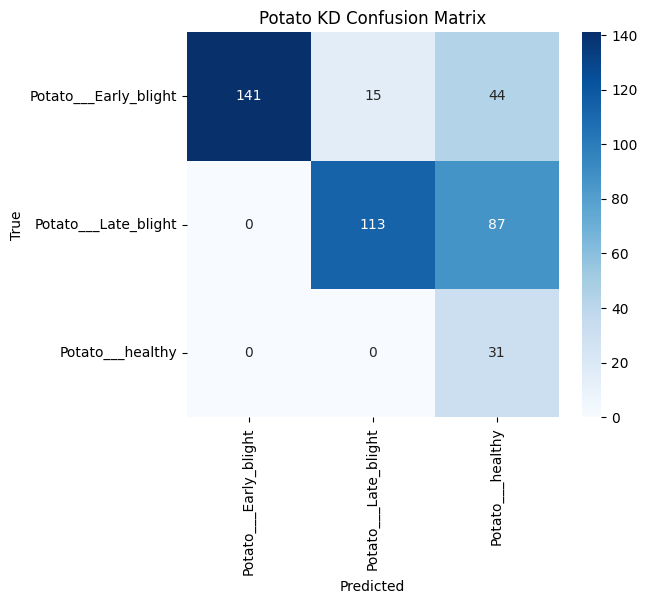

In [11]:
# CELL 7
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, cohen_kappa_score
import matplotlib.pyplot as plt
import seaborn as sns

y_true=[]; y_pred=[]; y_prob=[]
for xb, yb in test_ds:
    xb_n = tf.cast(xb, tf.float32) / 255.0
    probs = student(xb_n, training=False).numpy()
    preds = np.argmax(probs, axis=1)
    true = np.argmax(yb.numpy(), axis=1)
    y_true.extend(true); y_pred.extend(preds); y_prob.extend(probs)

y_true = np.array(y_true); y_pred = np.array(y_pred); y_prob = np.array(y_prob)

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
try:
    auc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='weighted')
except:
    auc = float('nan')
kappa = cohen_kappa_score(y_true, y_pred)

print("\nTEST RESULTS")
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1:", f1)
print("AUC:", auc)
print("Cohen Kappa:", kappa)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Potato KD Confusion Matrix')
plt.show()


In [12]:
# CELL 8
out = "/content/drive/MyDrive/student_mobilenet_potato_kd_finetuned.keras"
student.save(out)
print("Saved distilled student model to:", out)


Saved distilled student model to: /content/drive/MyDrive/student_mobilenet_potato_kd_finetuned.keras
